# Does the refusal axis read or only push?

Demo of the iteration-4 experiment **"read-vs-act"** on the refusal direction.

Each of 30 checkpoints over 7 lineages was measured in **both roles of the same five axes**
(A canned-response contrast, B token-disjoint paraphrase, C stylistic, D norm-matched random,
E prompt contrast):

* **DETECTION** — held-out AUROC of the axis projection on the model's *own* generated text
  (stratum-centred, prompt-clustered bootstrap).
* **INDUCTION** — a steering sweep in axis-contrast units `c = alpha * NORM_L / ||d_raw||`,
  reading off the refusal rate on benign prompts.

The GPU stage (loading 30 HuggingFace checkpoints, ~3.5 h on an RTX A4500) cannot run in Colab.
This notebook replays the **analysis stage that produces the headline H3 result**: the study's
first joint read-vs-act scatter, over 70 `(member, axis)` pairs — versus a previous evidence
base of 4 pairs. The question H3 asks is whether an axis that *reads* refusal well is the same
axis that *pushes* refusal well, or whether the two roles come apart.

Pre-registered answer shape: if the lineage-cluster bootstrap CI on Spearman rho contains zero,
the joint relationship is declared NULL. It does not — `rho = 0.629 [0.465, 0.803]`.

The code below is the original `h3_joint_scatter()` from `method.py` plus the three estimators
it calls from `explib.py` (`spearman`, `cluster_boot_indices`, `boot_ci`), copied as-is; only the
data source changed from per-member checkpoint files to the packaged demo JSON.


In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy, scipy, matplotlib, pandas — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0', 'pandas==2.2.2')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- original import block from method.py / explib.py (trimmed to what runs off-GPU) ---
import json
import math
import numpy as np

# notebook-only additions
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-c9546e-rating-model-safety-in-eighty-forward-pa/main/round-4/experiment-2/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["dataset"], "|", data["n_examples"], "examples")
print(data["description"])

joint_read_vs_act | 70 examples
One point per (member, axis): held-out detection AUROC of the axis projection on the model own generated text vs the maximum refusal rate induced by steering along the same axis. 70 pairs over 7 lineages, 14 members, 5 axes.


## Config

Every tunable of the analysis stage. `N_BOOT` and `BOOT_SEED` are the pre-registered values from
`explib.py` (2000 / 20260812); the bootstrap over 70 points is cheap, so the demo runs the full
pre-registered 2000 resamples. Lower `N_BOOT` to 200 for a faster smoke run — note `boot_ci()`
returns NaN below 20 finite resamples, which is the original's own guard.

In [5]:
# --- pre-registered constants (explib.py) ---
N_BOOT    = 2000        # ORIGINAL: 2000     (smoke value: 200)
BOOT_SEED = 20260812    # ORIGINAL: 20260812
CI_LO, CI_HI = 2.5, 97.5

# --- gates used by h3_joint_scatter ---
MIN_POINTS      = 4     # fewer than this -> "insufficient"
MIN_AXES_WITHIN = 4     # axes needed before a within-member rho is computed
MIN_UNCENSORED  = 4     # uncensored c_50 points needed for the secondary rho

AXES_ALL = data["constants"]["AXES_ALL"]
print("axes:", AXES_ALL)
print("N_BOOT =", N_BOOT, "| BOOT_SEED =", BOOT_SEED)

axes: ['A_canned', 'B_paraphrase', 'C_stylistic', 'D_random0', 'E_prompt_contrast']
N_BOOT = 2000 | BOOT_SEED = 20260812


## Estimators (copied verbatim from `explib.py`)

Three functions carry the whole inference:

* `spearman` — rank correlation, with the original's explicit NaN/constant-rank guards.
* `cluster_boot_indices` — resamples **lineages**, not points. Members of one lineage
  (base / instruct / abliterated of the same family) are not independent, so a naive
  point bootstrap would badly understate the CI.
* `boot_ci` — percentile CI, refusing to report below 20 finite resamples.

In [6]:
def cluster_boot_indices(clusters: np.ndarray, n_boot: int, seed: int):
    """Index arrays for a bootstrap resampling CLUSTERS (prompts) with replacement."""
    rng = np.random.default_rng(seed)
    uniq = np.unique(clusters)
    idx_by_c = {c: np.flatnonzero(clusters == c) for c in uniq}
    for _ in range(n_boot):
        pick = rng.choice(uniq, size=len(uniq), replace=True)
        yield np.concatenate([idx_by_c[c] for c in pick])


def boot_ci(vals, lo=CI_LO, hi=CI_HI):
    v = np.asarray([x for x in vals if np.isfinite(x)], float)
    if v.size < 20:
        return (float("nan"), float("nan"))
    return (float(np.percentile(v, lo)), float(np.percentile(v, hi)))


def spearman(x, y) -> float:
    from scipy.stats import rankdata
    x, y = np.asarray(x, float), np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 3:
        return float("nan")
    rx, ry = rankdata(x[ok]), rankdata(y[ok])
    if rx.std() < 1e-12 or ry.std() < 1e-12:
        return float("nan")
    return float(np.corrcoef(rx, ry)[0, 1])

## Rebuild the point list

In the original, `h3_joint_scatter` walks the per-member `detect_*.json` / `induce_*.json`
checkpoints and keeps a point only when the member is `powered` (had enough spontaneous refusals
to score) and its induction sweep produced a `max_rate`. That filtering already happened when
these 70 points were written out, so here the same records are unpacked from the demo JSON —
one point per `(member, axis)`, exactly the dict the original built.

In [7]:
pts = []
for ex in data["examples"]:
    pts.append({
        "checkpoint": ex["metadata_member"], "axis": ex["metadata_axis"],
        "lineage_id": ex["metadata_lineage_id"], "member_class": ex["metadata_level"],
        "level": ex["metadata_level"], "params_b": ex["metadata_params_b"],
        "detection_auroc": ex["metadata_detection_auroc"],
        "detection_ci95": ex["metadata_detection_ci95"],
        "detection_verdict": ex["output"],
        "max_refusal_rate": ex["metadata_max_refusal_rate"],
        "c_50": ex["metadata_c_50"],
        "neg_log10_c50": ex["metadata_neg_log10_c50"],
    })

print(f"{len(pts)} (member, axis) pairs | "
      f"{len({p['checkpoint'] for p in pts})} members | "
      f"{len({p['lineage_id'] for p in pts})} lineages")
for p in pts[:3]:
    print(p["checkpoint"], p["axis"], "AUROC=%.3f" % p["detection_auroc"],
          "max_rate=%.3f" % p["max_refusal_rate"], p["detection_verdict"])

70 (member, axis) pairs | 14 members | 7 lineages
Llama_3p2_1B_Instruct A_canned AUROC=0.691 max_rate=0.611 READS
Llama_3p2_1B_Instruct B_paraphrase AUROC=0.459 max_rate=0.833 AMBIGUOUS
Llama_3p2_1B_Instruct C_stylistic AUROC=0.434 max_rate=0.000 AMBIGUOUS


## H3 — the joint read-vs-act scatter

The body of `h3_joint_scatter()`, unchanged. `x` is induction quality (max refusal rate reached
anywhere on the contrast grid), `y` is detection quality (held-out AUROC). The primary CI comes
from the lineage-cluster bootstrap; a secondary rho uses `-log10(c_50)`, the contrast at which
refusal first crosses 0.50 — that one is heavily **censored**, since most axes never cross 0.50
at any contrast, which is why it is secondary and not the headline.

In [8]:
if len(pts) < MIN_POINTS:
    raise SystemExit({"n_pairs": len(pts), "insufficient": True})

y = np.array([p["detection_auroc"] for p in pts], float)
x = np.array([p["max_refusal_rate"] for p in pts], float)
lin = np.array([p["lineage_id"] for p in pts])
rho = spearman(x, y)

boots = []
for idx in cluster_boot_indices(lin, N_BOOT, BOOT_SEED):
    boots.append(spearman(x[idx], y[idx]))
lo, hi = boot_ci(boots)

unc = [p for p in pts if p["neg_log10_c50"] is not None]
rho_sec = (spearman([p["neg_log10_c50"] for p in unc],
                    [p["detection_auroc"] for p in unc])
           if len(unc) >= MIN_UNCENSORED else float("nan"))

within = []
for ck in sorted({p["checkpoint"] for p in pts}):
    sub = [p for p in pts if p["checkpoint"] == ck]
    if len(sub) >= MIN_AXES_WITHIN:
        within.append({"checkpoint": ck,
                       "rho": spearman([p["max_refusal_rate"] for p in sub],
                                       [p["detection_auroc"] for p in sub]),
                       "n_axes": len(sub)})
wr = [w["rho"] for w in within if np.isfinite(w["rho"])]

n, nl = len(pts), int(len(np.unique(lin)))
null = bool(np.isfinite(lo) and np.isfinite(hi) and lo <= 0 <= hi)
if null:
    sentence = (f"induction quality and detection quality on the same axis are "
                f"UNCORRELATED across {n} (member, axis) pairs over {nl} lineages "
                f"(Spearman rho = {rho:.3f}, lineage-bootstrap 95% CI "
                f"[{lo:.3f}, {hi:.3f}], which contains zero)")
else:
    sentence = (f"across {n} (member, axis) pairs over {nl} lineages, induction "
                f"quality and detection quality are correlated at rho = {rho:.3f} "
                f"[{lo:.3f}, {hi:.3f}]")

h3 = {"n_pairs": n, "n_lineages": nl, "n_members": len({p["checkpoint"] for p in pts}),
      "rho_primary": rho, "ci95_lineage_bootstrap": [lo, hi],
      "is_null": null, "pre_committed_sentence": sentence,
      "x_primary": "max_refusal_rate", "y": "detection_auroc",
      "rho_secondary_neg_log10_c50": rho_sec,
      "n_uncensored_c50": len(unc),
      "censored_fraction": float(1 - len(unc) / n),
      "within_member": within,
      "within_member_mean_rho": float(np.mean(wr)) if wr else None,
      "points": pts}

print(h3["pre_committed_sentence"])

across 70 (member, axis) pairs over 7 lineages, induction quality and detection quality are correlated at rho = 0.629 [0.465, 0.803]


## Gate against the archived run

`method_out.json` from the executed run is the reference. With the pre-registered `N_BOOT` and
`BOOT_SEED` the recomputation should be **bit-for-bit identical**, since the bootstrap is seeded
and the estimator is deterministic. A smaller `N_BOOT` moves only the CI endpoints.

In [9]:
ref = data["reference_results"]
rows = []
for k in ["n_pairs", "n_lineages", "n_members", "rho_primary",
          "rho_secondary_neg_log10_c50", "n_uncensored_c50", "censored_fraction",
          "within_member_mean_rho"]:
    a, b = h3[k], ref[k]
    ok = (a == b) if not isinstance(a, float) else abs(a - b) < 1e-9
    rows.append({"quantity": k, "recomputed": a, "archived": b, "match": ok})
for j, name in enumerate(["ci95_lo", "ci95_hi"]):
    a, b = h3["ci95_lineage_bootstrap"][j], ref["ci95_lineage_bootstrap"][j]
    rows.append({"quantity": name, "recomputed": a, "archived": b,
                 "match": abs(a - b) < 1e-9})
gate = pd.DataFrame(rows)
print(gate.to_string(index=False))
print()
print("GATE:", "PASS" if gate['match'].all() else
      f"{int(gate['match'].sum())}/{len(gate)} match (expected if N_BOOT was lowered)")

                   quantity  recomputed  archived  match
                    n_pairs   70.000000 70.000000   True
                 n_lineages    7.000000  7.000000   True
                  n_members   14.000000 14.000000   True
                rho_primary    0.628934  0.628934   True
rho_secondary_neg_log10_c50    0.447718  0.447718   True
           n_uncensored_c50   16.000000 16.000000   True
          censored_fraction    0.771429  0.771429   True
     within_member_mean_rho    0.714674  0.714674   True
                    ci95_lo    0.464770  0.464770   True
                    ci95_hi    0.803474  0.803474   True

GATE: PASS


## Results

Left: the joint scatter, one point per `(member, axis)`, coloured by axis. The canonical
axis A sits top-right — it both reads and pushes. The norm-matched random axis D is the
control, and note it does **not** sit at zero on either roll: a random direction still induces
refusal at >= 0.10 on 7 of 30 members panel-wide, a floor any steering claim must clear.

Right: the per-member rho, i.e. the same read-vs-act question asked *inside* one checkpoint
across its five axes — the mean is even higher than the pooled estimate.

H3  JOINT READ-vs-ACT
across 70 (member, axis) pairs over 7 lineages, induction quality and detection quality are correlated at rho = 0.629 [0.465, 0.803]

  verdict                     : NOT NULL
  Spearman rho (primary)      : 0.6289
  lineage-bootstrap 95% CI    : [0.4648, 0.8035]  (2000 resamples of 7 lineages)
  secondary rho on -log10 c50 : 0.4477 (n=16, censored fraction 0.771)
  within-member mean rho      : 0.7147 over 14 members

-- per axis ------------------------------------------------------------------
                    n  mean_auroc  mean_max_rate  n_reads
axis                                                     
A_canned           14       0.830          0.696       13
B_paraphrase       14       0.535          0.260        4
C_stylistic        14       0.356          0.026        0
D_random0          14       0.469          0.087        2
E_prompt_contrast  14       0.627          0.139        5

-- within-member rho -------------------------------------------------

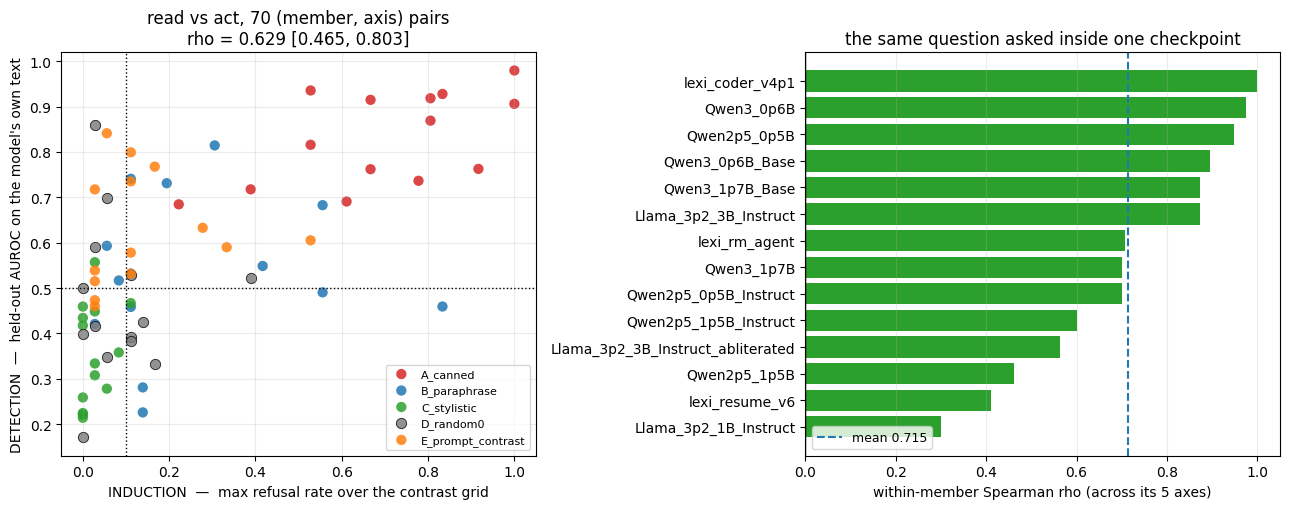

In [10]:
# ---------------- summary tables ----------------
df = pd.DataFrame(pts)

print("=" * 78)
print("H3  JOINT READ-vs-ACT")
print("=" * 78)
print(h3["pre_committed_sentence"])
print()
print(f"  verdict                     : {'NULL' if h3['is_null'] else 'NOT NULL'}")
print(f"  Spearman rho (primary)      : {h3['rho_primary']:.4f}")
print(f"  lineage-bootstrap 95% CI    : [{h3['ci95_lineage_bootstrap'][0]:.4f}, "
      f"{h3['ci95_lineage_bootstrap'][1]:.4f}]  ({N_BOOT} resamples of {h3['n_lineages']} lineages)")
print(f"  secondary rho on -log10 c50 : {h3['rho_secondary_neg_log10_c50']:.4f} "
      f"(n={h3['n_uncensored_c50']}, censored fraction {h3['censored_fraction']:.3f})")
print(f"  within-member mean rho      : {h3['within_member_mean_rho']:.4f} "
      f"over {len(h3['within_member'])} members")
print()

print("-- per axis " + "-" * 66)
per_axis = (df.groupby("axis")
              .agg(n=("axis", "size"),
                   mean_auroc=("detection_auroc", "mean"),
                   mean_max_rate=("max_refusal_rate", "mean"),
                   n_reads=("detection_verdict", lambda s: (s == "READS").sum()))
              .reindex(AXES_ALL))
print(per_axis.to_string(float_format=lambda v: f"{v:.3f}"))
print()

print("-- within-member rho " + "-" * 57)
wm = pd.DataFrame(h3["within_member"]).sort_values("rho", ascending=False)
print(wm.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print()

print("-- detection verdicts " + "-" * 56)
print(df["detection_verdict"].value_counts().to_string())

# ---------------- figure ----------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

ax = axes[0]
colors = dict(zip(AXES_ALL, ["#d62728", "#1f77b4", "#2ca02c", "#7f7f7f", "#ff7f0e"]))
for a in AXES_ALL:
    sub = df[df.axis == a]
    ax.scatter(sub.max_refusal_rate, sub.detection_auroc, s=55, alpha=0.85,
               label=a, color=colors[a],
               edgecolor="k" if a == "D_random0" else "none", linewidth=0.6)
ax.axhline(0.5, color="k", ls=":", lw=1)
ax.axvline(0.10, color="k", ls=":", lw=1)
ax.set_xlabel("INDUCTION  —  max refusal rate over the contrast grid")
ax.set_ylabel("DETECTION  —  held-out AUROC on the model's own text")
ax.set_title(f"read vs act, {h3['n_pairs']} (member, axis) pairs\n"
             f"rho = {h3['rho_primary']:.3f} "
             f"[{h3['ci95_lineage_bootstrap'][0]:.3f}, {h3['ci95_lineage_bootstrap'][1]:.3f}]")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.25)

ax = axes[1]
wm2 = wm.iloc[::-1]
ax.barh(wm2.checkpoint, wm2.rho, color=["#2ca02c" if v > 0 else "#d62728" for v in wm2.rho])
ax.axvline(0, color="k", lw=1)
ax.axvline(h3["within_member_mean_rho"], color="#1f77b4", ls="--", lw=1.5,
           label=f"mean {h3['within_member_mean_rho']:.3f}")
ax.set_xlabel("within-member Spearman rho (across its 5 axes)")
ax.set_title("the same question asked inside one checkpoint")
ax.legend(fontsize=9, loc="lower left")
ax.grid(alpha=0.25, axis="x")

plt.tight_layout()
plt.show()